### Final Project: Applied Machine Learning for a FinTech Startup

### "Loan Approval Prediction Using Machine Learning"

# Project Overview
# This project applies machine learning to predict loan approval outcomes using the Loan Prediction Dataset. The workflow includes data cleaning, exploratory analysis, feature engineering, model training, and performance evaluation. Two models are developed and compared, and SHAP is used to interpret the final model’s predictions and provide transparency into the decision-making process.

# Clean the Dataset

In [12]:
import pandas as pd
import numpy as np
df = pd.read_csv("loan_predication.csv")   
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing values (%):")
print((df.isna().mean() * 100).sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())
# Removed the duplicates
df = df.drop_duplicates()
# Clean text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
# Drop Loan_ID (not useful for prediction)
if "Loan_ID" in df.columns:
    df = df.drop(columns=["Loan_ID"])
#  Fix Dependents column
if "Dependents" in df.columns:
    df["Dependents"] = df["Dependents"].replace("3+", "3")
    df["Dependents"] = pd.to_numeric(df["Dependents"], errors="coerce")

#  Convert Loan_Status to 1/0
if "Loan_Status" in df.columns:
    df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})
# Convert numeric-like columns to numeric
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", 
                "Loan_Amount_Term", "Credit_History"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
# Fill missing values (for EDA only)
# Numeric -> median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical -> mode
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].replace("nan", np.nan)
    df[col] = df[col].fillna(df[col].mode()[0])

# Final check
print("\nFinal missing values:")
print(df.isna().sum())

df.head()


Shape: (614, 13)

Columns: Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Missing values (%):
Credit_History       8.143322
Self_Employed        5.211726
LoanAmount           3.583062
Dependents           2.442997
Loan_Amount_Term     2.280130
Gender               2.117264
Married              0.488599
Loan_ID              0.000000
Education            0.000000
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

Duplicate rows: 0

Final missing values:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Sta

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


## Imports

In [14]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

import shap

# Exploratory Data Analysis

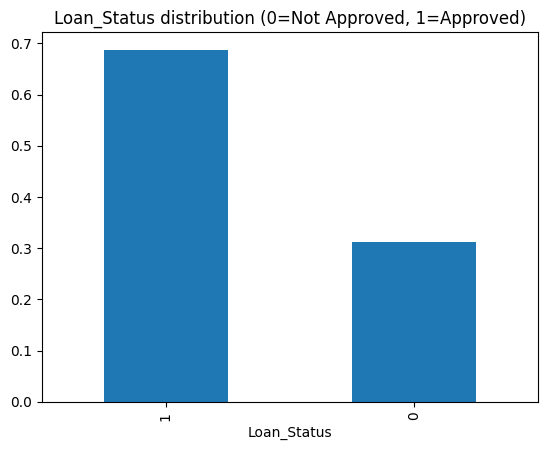

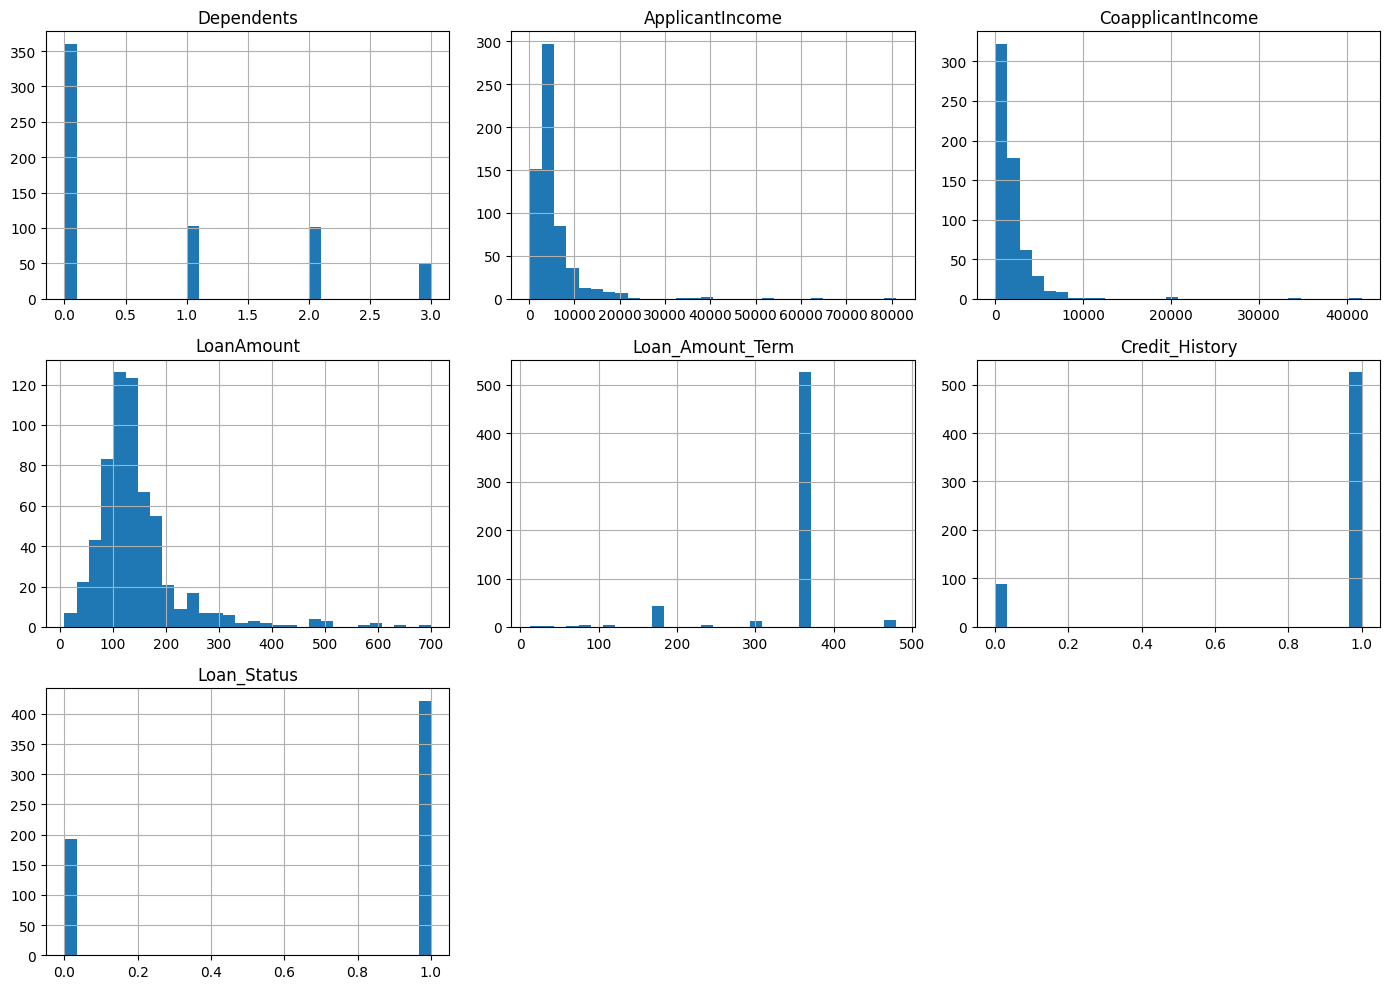


Approval rate by Credit_History:
Credit_History
1.0    0.790476
0.0    0.078652
Name: Loan_Status, dtype: float64

Approval rate by Education:
Education
Graduate        0.708333
Not Graduate    0.611940
Name: Loan_Status, dtype: float64

Approval rate by Married:
Married
Yes    0.718204
No     0.629108
Name: Loan_Status, dtype: float64

Approval rate by Self_Employed:
Self_Employed
No     0.687970
Yes    0.682927
Name: Loan_Status, dtype: float64

Approval rate by Property_Area:
Property_Area
Semiurban    0.768240
Urban        0.658416
Rural        0.614525
Name: Loan_Status, dtype: float64


In [16]:
# Target distribution
df["Loan_Status"].value_counts(normalize=True).plot(kind="bar")
plt.title("Loan_Status distribution (0=Not Approved, 1=Approved)")
plt.show()

# Numeric distributions
num_cols_eda = df.select_dtypes(include=[np.number]).columns
df[num_cols_eda].hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

# Approval rate by key columns (if they exist)
for col in ["Credit_History", "Education", "Married", "Self_Employed", "Property_Area"]:
    if col in df.columns:
        print(f"\nApproval rate by {col}:")
        print(df.groupby(col)["Loan_Status"].mean().sort_values(ascending=False))


In [17]:
#The EDA shows that most loans in the dataset are approved, which means the data is slightly imbalanced. Income and loan amount distributions are
#right skewed, so most applicants earn moderate incomes and take smaller loans, while a few have very large values.
#Credit history is the strongest factor: applicants with a good credit history are much more likely to be approved than those without one. 
#Education, marital status, self-employment, and property area also affect approval rates, but to a smaller degree.

# Feature engineering

In [19]:
X = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"].astype(int)

X_fe = X.copy()

# Create TotalIncome and ratios (common credit risk features)
if set(["ApplicantIncome", "CoapplicantIncome"]).issubset(X_fe.columns):
    X_fe["TotalIncome"] = X_fe["ApplicantIncome"] + X_fe["CoapplicantIncome"]
    X_fe["LogTotalIncome"] = np.log1p(X_fe["TotalIncome"])

if set(["TotalIncome", "LoanAmount"]).issubset(X_fe.columns):
    X_fe["IncomeLoanRatio"] = X_fe["TotalIncome"] / (X_fe["LoanAmount"] + 1e-6)

# Optional: EMIs approx (LoanAmount / Term) if term exists
if set(["LoanAmount", "Loan_Amount_Term"]).issubset(X_fe.columns):
    X_fe["LoanPerTerm"] = X_fe["LoanAmount"] / (X_fe["Loan_Amount_Term"] + 1e-6)

X_fe.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,LogTotalIncome,IncomeLoanRatio,LoanPerTerm
0,Male,No,0.0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,5849.0,8.674197,45.695312,0.355556
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,6091.0,8.714732,47.585937,0.355556
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,3000.0,8.006701,45.454545,0.183333
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,4941.0,8.505525,41.175000,0.333333
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,6000.0,8.699681,42.553191,0.391667


In [20]:
# Totalincome, IncomeLoanRatio, LoanPerTerm have been added to the data set. This helps the machine learning model make more accurate and meaningful
# loan approvel predictions. 

### Train, Test split 

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (491, 15) Test shape: (123, 15)


In [23]:
# The dataset splitted into training and testing sets, 491 rows are used to train the machine learning model. 123 rows are kept aside for
# testing how well the model performs on new, unseen date, both contain 15 features. 

### Preprocessing pipeline

In [25]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

### Model 1 (Baseline): Logistic Regression

In [27]:
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

baseline.fit(X_train, y_train)
p_base = baseline.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, p_base))
print("Logistic Regression PR-AUC:", average_precision_score(y_test, p_base))


Logistic Regression ROC-AUC: 0.8606811145510835
Logistic Regression PR-AUC: 0.9063063753159795


### Model 2 (Primary): Random Forest

In [29]:
primary = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced"
    ))
])

primary.fit(X_train, y_train)
p_rf = primary.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC:", roc_auc_score(y_test, p_rf))
print("Random Forest PR-AUC:", average_precision_score(y_test, p_rf))

Random Forest ROC-AUC: 0.8561919504643962
Random Forest PR-AUC: 0.8910304031635105


### Evaluation 

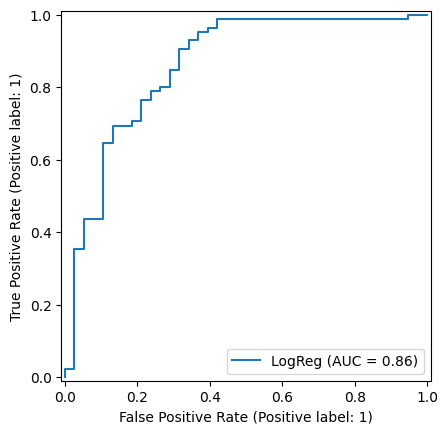

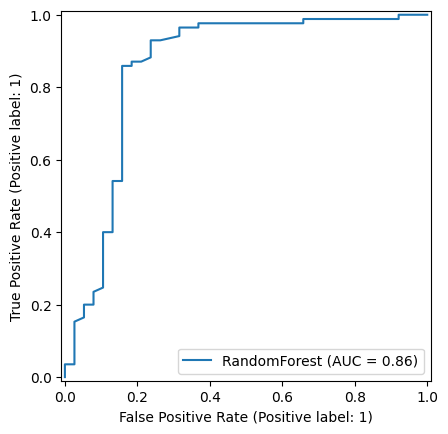

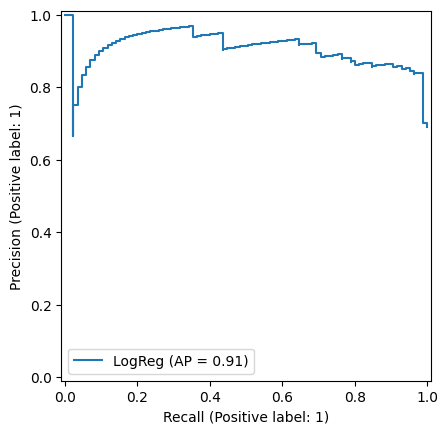

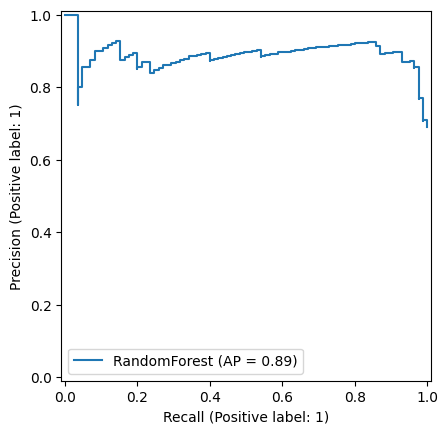


Random Forest Classification Report (thr=0.5):
              precision    recall  f1-score   support

           0      0.893     0.658     0.758        38
           1      0.863     0.965     0.911        85

    accuracy                          0.870       123
   macro avg      0.878     0.811     0.834       123
weighted avg      0.872     0.870     0.864       123

Confusion Matrix:
 [[25 13]
 [ 3 82]]


In [31]:
# ROC curve
RocCurveDisplay.from_predictions(y_test, p_base, name="LogReg")
RocCurveDisplay.from_predictions(y_test, p_rf, name="RandomForest")
plt.show()

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, p_base, name="LogReg")
PrecisionRecallDisplay.from_predictions(y_test, p_rf, name="RandomForest")
plt.show()

# Threshold-based evaluation (default 0.5)
thr = 0.5
yhat_rf = (p_rf >= thr).astype(int)

print("\nRandom Forest Classification Report (thr=0.5):")
print(classification_report(y_test, yhat_rf, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, yhat_rf))

In [32]:
# Both Logistic Regression and Random Forest achieve a ROC-AUC of about 0.86, showing they can clearly distinguish between approved and rejected loans. 
#The Precision–Recall curves indicate that both models perform well on this imbalanced dataset, with Logistic Regression having slightly higher average
# precision. The Random Forest model correctly identifies most approved loans, with a recall of about 96.5%. Its overall accuracy is around 87%,
# which indicates strong predictive performance. The confusion matrix shows only a few approved loans were missed, making the model reliable for
# supporting loan approval decisions.

# SHAP Explainability (for Random Forest)

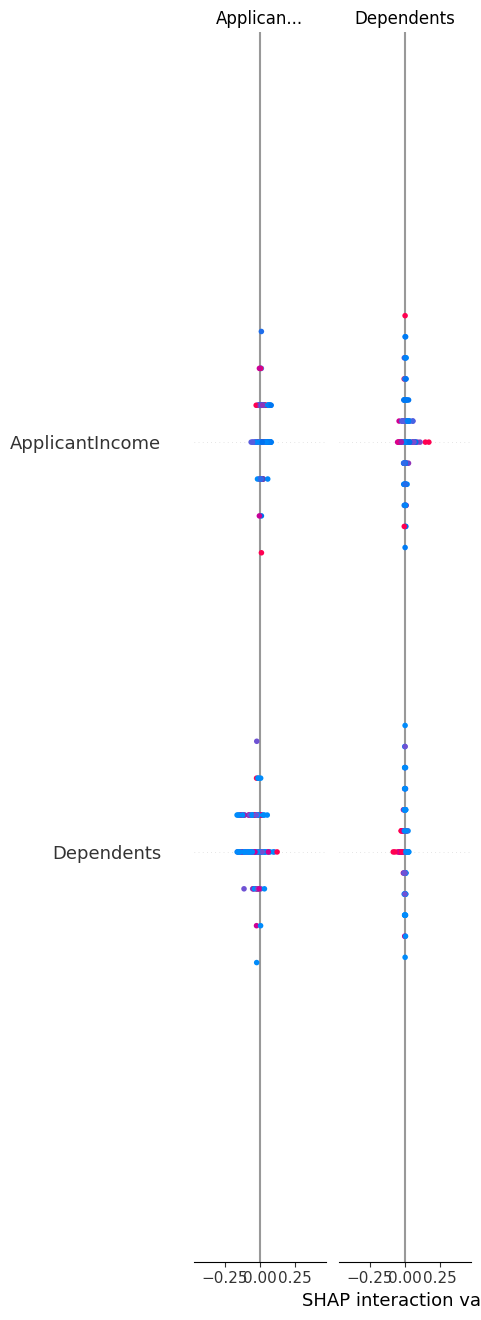

In [34]:
# Fit preprocessing separately so we can transform and get feature names
preprocess_fitted = preprocess.fit(X_train)

X_train_t = preprocess_fitted.transform(X_train)
X_test_t  = preprocess_fitted.transform(X_test)

# Feature names after one-hot encoding
num_features = num_cols
ohe = preprocess_fitted.named_transformers_["cat"].named_steps["onehot"] if len(cat_cols) else None
cat_features = ohe.get_feature_names_out(cat_cols).tolist() if ohe is not None else []
feature_names = num_features + cat_features

rf_model = primary.named_steps["clf"]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_t)

# For binary classification: use class 1 explanations
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Global explanation
shap.summary_plot(sv, X_test_t, feature_names=feature_names, max_display=15)

In [35]:
 # This SHAP plot shows how individual features affect the loan approval predictions made by the model. Each dot represents one applicant, 
# and its position shows whether that feature pushes the prediction toward approval or rejection. The colors indicate low (blue) and high (red) values 
# of the feature. From the plot, ApplicantIncome and Dependents have a strong influence on the model’s decisions, where higher income generally
# increases approval chances, while having more dependents can reduce them. This output helps explain how the model is making its predictions in
# a transparent way.

### Local explanation (one applicant)

In [37]:
print("X_test_t shape:", X_test_t.shape)
print("sv shape:", np.array(sv).shape)
print("len(feature_names):", len(feature_names))


X_test_t shape: (123, 21)
sv shape: (123, 21, 2)
len(feature_names): 21


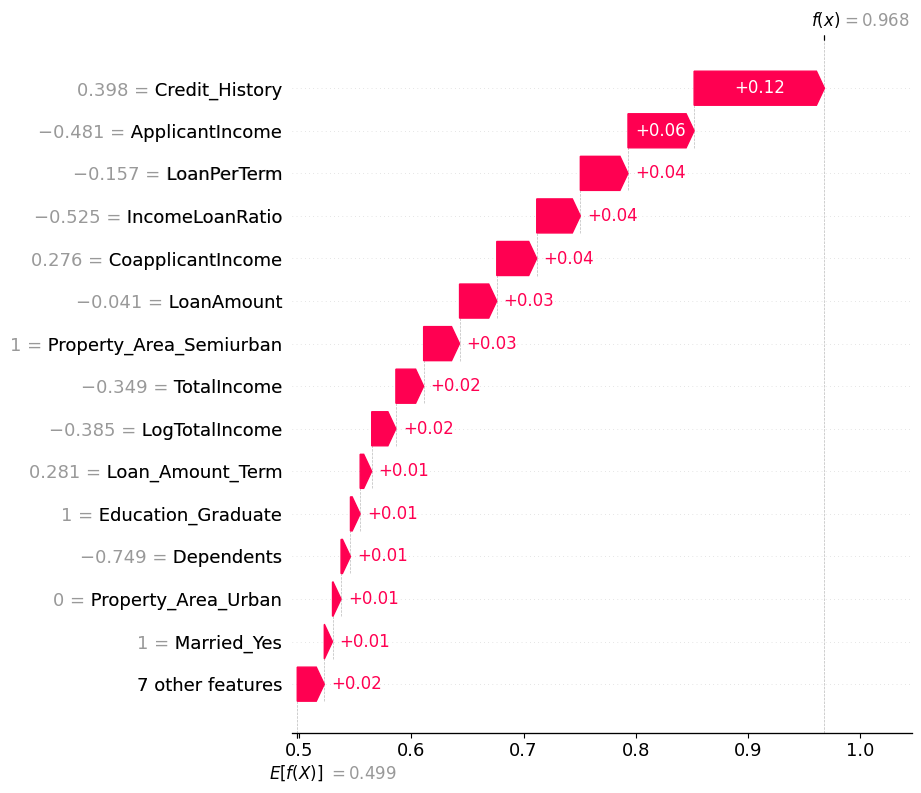

Selected applicant approval probability: 0.968


In [38]:
# choose one applicant (most likely approved)
i = int(np.argmax(p_rf))

# take SHAP values for class 1 (Approved)
sv_class1 = sv[:, :, 1]   # shape becomes (123, 21)

# build an Explanation object for one row
row_vals = X_test_t[i].toarray()[0] if hasattr(X_test_t, "toarray") else X_test_t[i]

exp = shap.Explanation(
    values=sv_class1[i],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    data=row_vals,
    feature_names=feature_names
)

# best local explanation plot for reports
shap.plots.waterfall(exp, max_display=15)

print("Selected applicant approval probability:", p_rf[i])


In [39]:
#This graph explains why the model approved one specific loan application. It starts from the avarage approval chance and shows how each feature 
#moves the prediction up and down until it reaches 0.968. Features like Credit history and Applicant Income increase the chance of approval. 
#other factors like loan size, income ratio, and number of dependents slightly reduce it. 

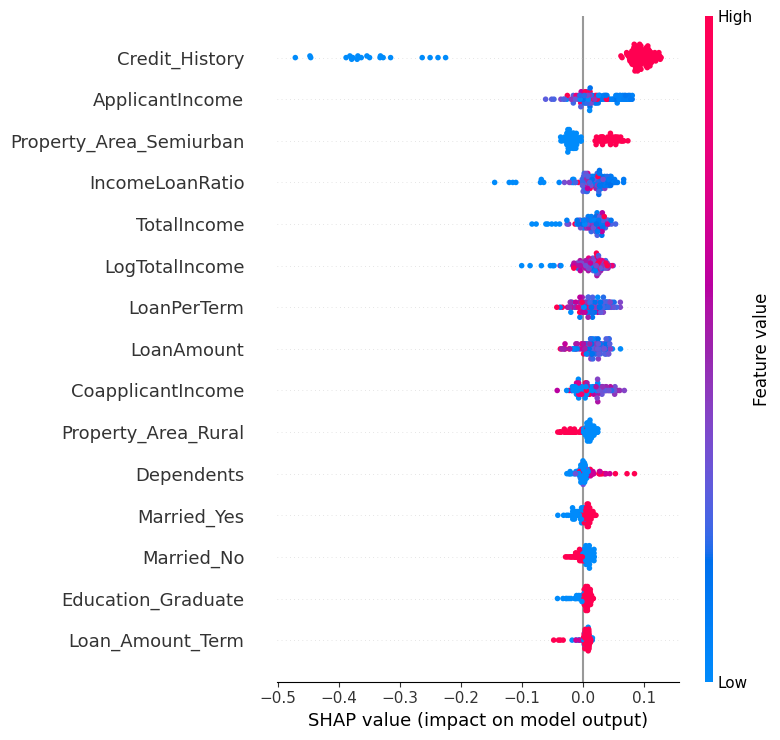

In [40]:
shap.summary_plot(sv_class1, X_test_t, feature_names=feature_names, max_display=15)


In [41]:
# This SHAP summary plot shows which features are most important for the model overall and how they affect loan approval. 
# Credit History is clearly the most important factor- having a good credit history strongly increases approval. Applicant Income
# Property Area, and Income-Loan Ratio are also important, whereas Loan Amount Term, Education and Marriage status are have little influence on 
# whether a loan is approved compared to strong drivers like Credit History and Income. 

# Loan Approval Prediction Calculator

In [43]:
import numpy as np
import pandas as pd

def make_features_from_inputs(
    Gender, Married, Dependents, Education, Self_Employed,
    ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term,
    Credit_History, Property_Area
):
    """
    Create a single-row dataframe in the same format as the training data
    (including engineered features).
    """

    # Convert Dependents safely (allow "3+")
    if isinstance(Dependents, str):
        Dependents = Dependents.strip().replace("3+", "3")
    try:
        Dependents_num = float(Dependents)
    except:
        Dependents_num = np.nan

    # Base features (match dataset columns)
    row = {
        "Gender": Gender,
        "Married": Married,
        "Dependents": Dependents_num,
        "Education": Education,
        "Self_Employed": Self_Employed,
        "ApplicantIncome": float(ApplicantIncome),
        "CoapplicantIncome": float(CoapplicantIncome),
        "LoanAmount": float(LoanAmount),
        "Loan_Amount_Term": float(Loan_Amount_Term),
        "Credit_History": float(Credit_History),
        "Property_Area": Property_Area
    }

    X_new = pd.DataFrame([row])

    # Feature engineering
    X_new["TotalIncome"] = X_new["ApplicantIncome"] + X_new["CoapplicantIncome"]
    X_new["LogTotalIncome"] = np.log1p(X_new["TotalIncome"])
    X_new["IncomeLoanRatio"] = X_new["TotalIncome"] / (X_new["LoanAmount"] + 1e-6)
    X_new["LoanPerTerm"] = X_new["LoanAmount"] / (X_new["Loan_Amount_Term"] + 1e-6)

    return X_new


def loan_approval_calculator(model, threshold=0.5, **inputs):
    """
    model: your trained pipeline (e.g., primary or baseline)
    threshold: classification cutoff for Approved vs Not Approved
    inputs: keyword args for the applicant fields
    """

    X_new = make_features_from_inputs(**inputs)

    prob_approved = model.predict_proba(X_new)[:, 1][0]
    decision = "Approved " if prob_approved >= threshold else "Not Approved "

    print("---- Loan Approval Prediction ----")
    print(f"Approval probability: {prob_approved:.3f}")
    print(f"Decision (threshold={threshold}): {decision}")
    return prob_approved, decision, X_new

In [44]:
prob, decision, X_example = loan_approval_calculator(
    model=primary,          # or baseline
    threshold=0.5,
    Gender="Male",
    Married="Yes",
    Dependents="1",
    Education="Graduate",
    Self_Employed="No",
    ApplicantIncome=5000,
    CoapplicantIncome=2000,
    LoanAmount=150,
    Loan_Amount_Term=360,
    Credit_History=1,
    Property_Area="Semiurban"
)

X_example

---- Loan Approval Prediction ----
Approval probability: 0.760
Decision (threshold=0.5): Approved 


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,LogTotalIncome,IncomeLoanRatio,LoanPerTerm
0,Male,Yes,1.0,Graduate,No,5000.0,2000.0,150.0,360.0,1.0,Semiurban,7000.0,8.853808,46.666666,0.416667


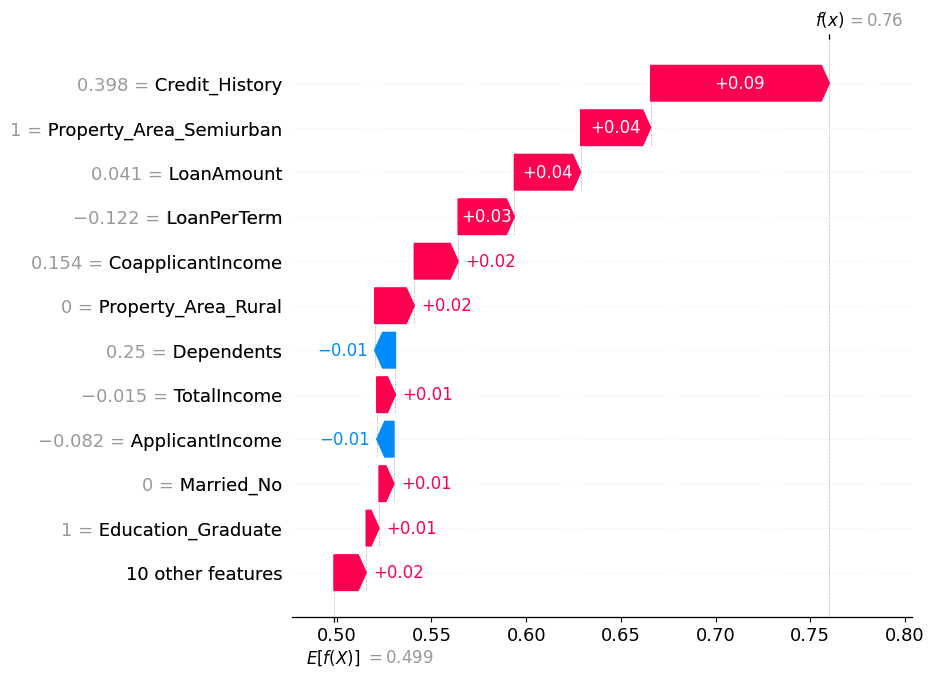

In [45]:
# Transform the new row using your fitted preprocess
X_new_t = preprocess_fitted.transform(X_example)

# Get SHAP values (for Random Forest model)
shap_vals_new = explainer.shap_values(X_new_t)

# Handle multi-class formats: choose class 1 (Approved)
sv_new = shap_vals_new[1] if isinstance(shap_vals_new, list) else shap_vals_new
if sv_new.ndim == 3:  # if shape is (samples, features, 2)
    sv_new = sv_new[:, :, 1]

row_vals = X_new_t.toarray()[0] if hasattr(X_new_t, "toarray") else X_new_t[0]

exp_new = shap.Explanation(
    values=sv_new[0],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    data=row_vals,
    feature_names=feature_names
)

shap.plots.waterfall(exp_new, max_display=12)
